In [39]:
import os
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [ ]:
path = './Dataset'
label_list = []
for dirs in os.listdir(path):
    label_list.append(dirs)

images = []
classes = []

for i, label in enumerate(label_list):
    full_path = os.path.join(path, label)
    for j, image in enumerate(os.listdir(full_path)):
        img_path = os.path.join(full_path, image)
        img = load_img(img_path)
        img = img_to_array(img)
        img = tf.image.rgb_to_grayscale(img)
        img = img / 255

        images.append(img)
        classes.append(i)

In [41]:
y = tf.keras.utils.to_categorical(classes, len(label_list))
images = np.asarray(images)

In [42]:
x_train, x_temp, y_train, y_temp = train_test_split(images, y, train_size=0.8, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, train_size=0.5, random_state=42)

In [43]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, activation='relu', kernel_size=(3, 3), strides=(1, 1), padding='same', input_shape=(224, 224, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(16, activation='relu', kernel_size=(3, 3), strides=(1, 1), padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax'),
])

c:\Github\deep-learning\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
history = model.fit(
    x_train, 
    y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    callbacks=early_stopping
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.4306 - loss: 1.2234 - val_accuracy: 0.5250 - val_loss: 1.0061
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7719 - loss: 0.6307 - val_accuracy: 0.7950 - val_loss: 0.5175
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8581 - loss: 0.3942 - val_accuracy: 0.7800 - val_loss: 0.5174
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9081 - loss: 0.2764 - val_accuracy: 0.8200 - val_loss: 0.5090
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9112 - loss: 0.2442 - val_accuracy: 0.7500 - val_loss: 0.6934
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9337 - loss: 0.1821 - val_accuracy: 0.7800 - val_loss: 0.5246
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9550 - loss: 0.1326 - val_accuracy: 0.8550 - val_loss: 0.4702
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9712 - loss: 0.0841 - val_accuracy: 0.8850 - v

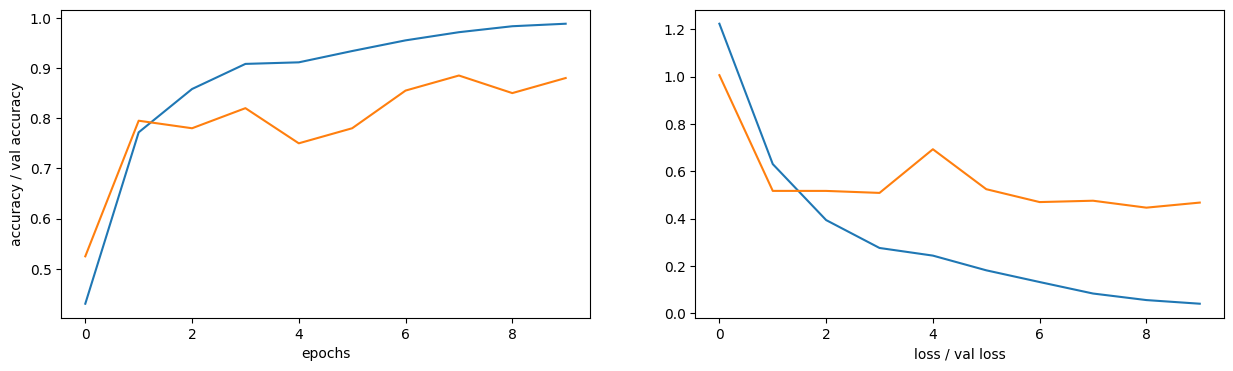

In [46]:
plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy / val accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.xlabel('loss / val loss')

plt.show()

In [47]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=2)
print('test loss: ', loss)
print('test accuracy: ', accuracy)

from sklearn.metrics import classification_report
y_preds_probs = model.predict(x_test)
y_pred = np.argmax(y_preds_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=label_list))

7/7 - 0s - 14ms/step - accuracy: 0.9200 - loss: 0.3216
test loss:  0.321554958820343
test accuracy:  0.9200000166893005
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
              precision    recall  f1-score   support

    Broccoli       0.88      0.93      0.90        54
      Carrot       0.96      0.98      0.97        53
    Cucumber       0.95      0.90      0.93        41
      Tomato       0.90      0.87      0.88        52

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200

